# Car Market Trends Analysis with Car Dekho Data

This notebook performs exploratory data analysis on Car Dekho used-car data to understand market trends and factors influencing selling prices.

## Objectives
- Explore the structure and quality of the dataset.
- Analyze selling-price patterns.
- Study the effect of fuel type, transmission and seller type.
- Examine vehicle age and other factors related to car pricing.
- Visualize important market insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Hp\\Desktop\\Advanced_Data_Sciecne-LAB\\Assignment_3\\Project4\\1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Dataset Overview

In [2]:
print('Dataset Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
df.info()

Dataset Shape: (301, 9)

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## Data Quality Check

In [3]:
print('Missing Values:')
print(df.isnull().sum())

print('\nDuplicate Rows:', df.duplicated().sum())

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate Rows: 2


## Feature Engineering: Car Age

In [4]:
# Calculate car age using the current analysis year
df['Car_Age'] = 2026 - df['Year']
df[['Car_Name', 'Year', 'Car_Age', 'Selling_Price']].head()

,Car_Name,Year,Car_Age,Selling_Price
0,ritz,2014,12,3.35
1,sx4,2013,13,4.75
2,ciaz,2017,9,7.25
3,wagon r,2011,15,2.85
4,swift,2014,12,4.60


## Overall Market Analysis

In [5]:
print(f"Total Cars: {len(df)}")
print(f"Average Selling Price: {df['Selling_Price'].mean():.2f}")
print(f"Median Selling Price: {df['Selling_Price'].median():.2f}")
print(f"Highest Selling Price: {df['Selling_Price'].max():.2f}")

df[['Year','Selling_Price','Present_Price','Kms_Driven','Car_Age']].describe()

Total Cars: 301
Average Selling Price: 4.66
Median Selling Price: 3.60
Highest Selling Price: 35.00


,Year,Selling_Price,Present_Price,Kms_Driven,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,12.372093
std,2.891554,5.082812,8.644115,38886.883882,2.891554
min,2003.000000,0.100000,0.320000,500.000000,8.000000
25%,2012.000000,0.900000,1.200000,15000.000000,10.000000
50%,2014.000000,3.600000,6.400000,32000.000000,12.000000
75%,2016.000000,6.000000,9.900000,48767.000000,14.000000
max,2018.000000,35.000000,92.600000,500000.000000,23.000000


## Average Selling Price by Fuel Type

Fuel_Type
Diesel    10.278500
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64


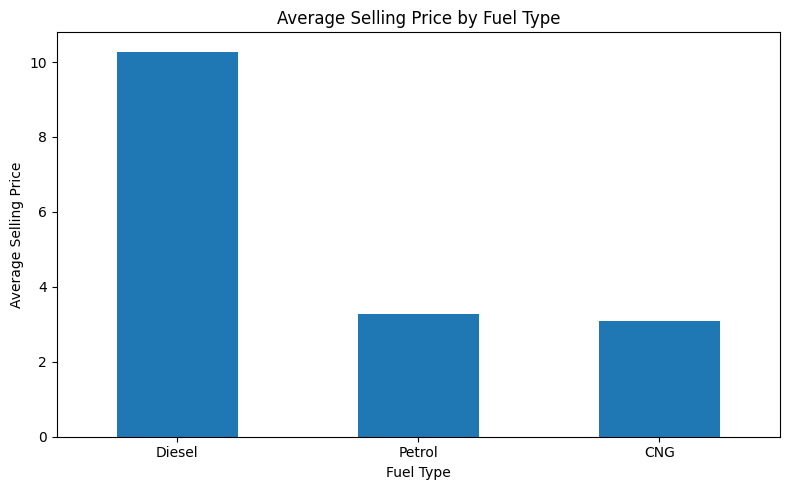

In [6]:
fuel_price = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
print(fuel_price)

plt.figure(figsize=(8,5))
fuel_price.plot(kind='bar')
plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Average Selling Price by Transmission

Transmission
Automatic    9.420000
Manual       3.931992
Name: Selling_Price, dtype: float64


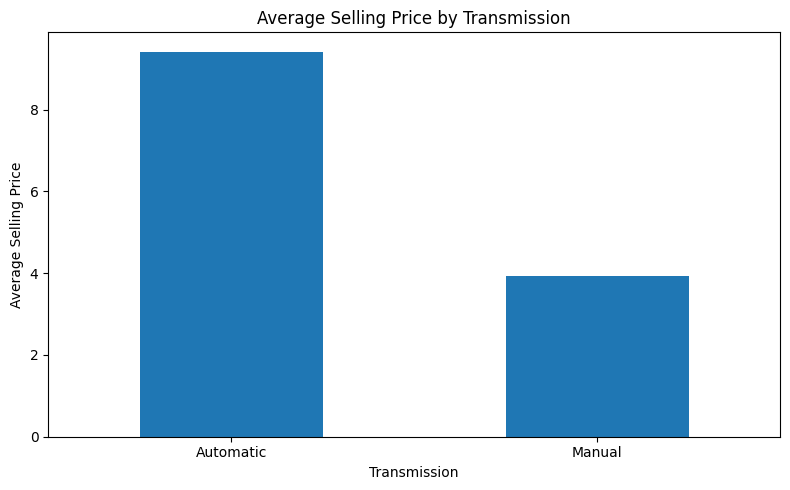

In [7]:
transmission_price = df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
print(transmission_price)

plt.figure(figsize=(8,5))
transmission_price.plot(kind='bar')
plt.title('Average Selling Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Average Selling Price by Seller Type

Seller_Type
Dealer        6.721692
Individual    0.870943
Name: Selling_Price, dtype: float64


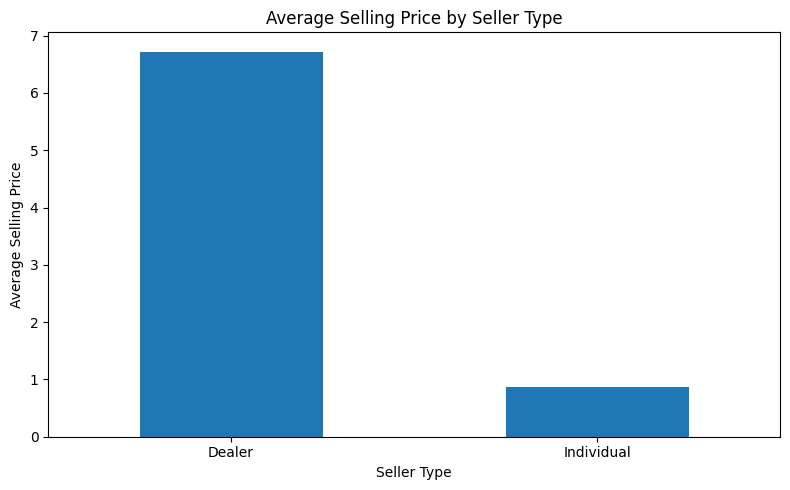

In [8]:
seller_price = df.groupby('Seller_Type')['Selling_Price'].mean().sort_values(ascending=False)
print(seller_price)

plt.figure(figsize=(8,5))
seller_price.plot(kind='bar')
plt.title('Average Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Car Age and Selling Price

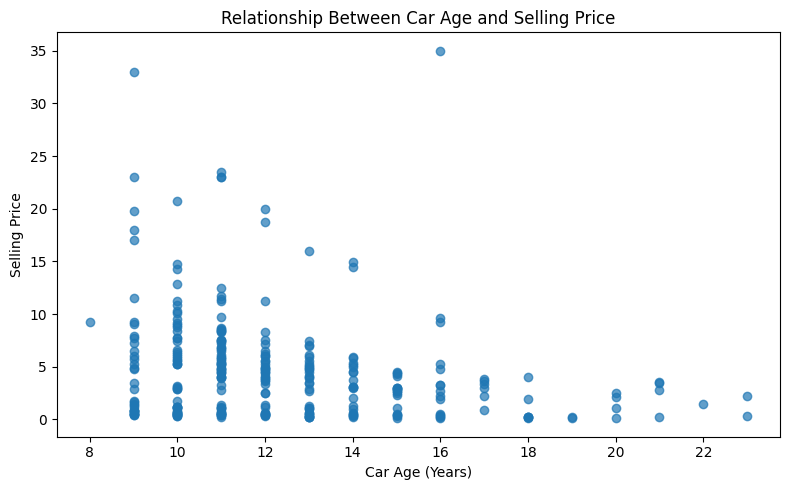

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df['Car_Age'], df['Selling_Price'], alpha=0.7)
plt.title('Relationship Between Car Age and Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()

## Conclusion

The analysis explores important trends in the used-car market using Car Dekho data. Vehicle characteristics such as fuel type, transmission, seller type and age are compared to understand differences in selling prices.

This project demonstrates a complete data analytics workflow including data loading, quality checks, feature engineering, exploratory analysis and visualization. The results can support used-car pricing and market analysis.